In [114]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nehapatel8969/exoplant/preprocessed.csv


In [115]:
# ===============================
# Import Libraries
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

In [116]:
# ===============================
# Imports & Global Configuration
# ===============================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.2

In [117]:
# ===============================
# Data Loading
# ===============================

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    print("Dataset Shape:", df.shape)
    return df

df = load_data("/kaggle/input/datasets/nehapatel8969/exoplant/preprocessed.csv")
df.head()

Dataset Shape: (6100, 34)


,planet_name,host_star_name,radius_earth,pl_radj,mass_earth,pl_massj,orbital_period,semimajor_axis,eq_temp_k,density,...,radius_earth_scaled,mass_earth_scaled,orbital_period_scaled,semimajor_axis_scaled,eq_temp_k_scaled,density_scaled,star_temp_k_scaled,star_luminosity_scaled,star_metallicity_scaled,habitable_binary
0,11 Com b,11 Com,2.42,NaN,196.050555,NaN,323.21000,1.178,811.0,1.33,...,0.0,0.000000,10.220065,5.369859,0.0,0.0,-0.768936,2.00510,-1.142857,0
1,11 UMi b,11 UMi,2.42,NaN,196.050555,NaN,516.21997,1.530,811.0,1.33,...,0.0,0.000000,16.539934,7.129485,0.0,0.0,-1.491933,0.00000,0.000000,0
2,14 And b,14 And,2.42,NaN,196.050555,NaN,186.76000,0.775,811.0,1.33,...,0.0,0.000000,5.752181,3.355287,0.0,0.0,-0.753623,1.86679,-0.904762,0
3,14 Her b,14 Her,2.42,NaN,2559.472162,8.053,1765.03890,2.774,811.0,1.33,...,0.0,2363.421607,57.430941,13.348164,0.0,0.0,0.000000,0.00000,0.000000,0
4,16 Cyg B b,16 Cyg B,2.42,NaN,196.050555,NaN,798.50000,1.660,811.0,1.33,...,0.0,0.000000,25.782839,7.779347,0.0,0.0,0.189226,0.00000,0.380952,0


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6100 entries, 0 to 6099
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   planet_name              6100 non-null   object 
 1   host_star_name           6100 non-null   object 
 2   radius_earth             6100 non-null   float64
 3   pl_radj                  4581 non-null   float64
 4   mass_earth               6100 non-null   float64
 5   pl_massj                 1954 non-null   float64
 6   orbital_period           6100 non-null   float64
 7   semimajor_axis           6100 non-null   float64
 8   eq_temp_k                6100 non-null   float64
 9   density                  6100 non-null   float64
 10  star_temp_k              6100 non-null   float64
 11  star_luminosity          6100 non-null   float64
 12  star_metallicity         6100 non-null   float64
 13  star_spectype            6100 non-null   object 
 14  habitability_score      

In [119]:
print(df.head())
print(df.columns)

  planet_name host_star_name  radius_earth  pl_radj   mass_earth  pl_massj  \
0    11 Com b         11 Com          2.42      NaN   196.050555       NaN   
1    11 UMi b         11 UMi          2.42      NaN   196.050555       NaN   
2    14 And b         14 And          2.42      NaN   196.050555       NaN   
3    14 Her b         14 Her          2.42      NaN  2559.472162     8.053   
4  16 Cyg B b       16 Cyg B          2.42      NaN   196.050555       NaN   

   orbital_period  semimajor_axis  eq_temp_k  density  ...  \
0       323.21000           1.178      811.0     1.33  ...   
1       516.21997           1.530      811.0     1.33  ...   
2       186.76000           0.775      811.0     1.33  ...   
3      1765.03890           2.774      811.0     1.33  ...   
4       798.50000           1.660      811.0     1.33  ...   

   radius_earth_scaled  mass_earth_scaled  orbital_period_scaled  \
0                  0.0           0.000000              10.220065   
1                  0.0

In [120]:
print(df.columns.tolist())

['planet_name', 'host_star_name', 'radius_earth', 'pl_radj', 'mass_earth', 'pl_massj', 'orbital_period', 'semimajor_axis', 'eq_temp_k', 'density', 'star_temp_k', 'star_luminosity', 'star_metallicity', 'star_spectype', 'habitability_score', 'stellar_compatibility', 'orbital_stability', 'star_A', 'star_B', 'star_F', 'star_G', 'star_K', 'star_M', 'star_Unknown', 'radius_earth_scaled', 'mass_earth_scaled', 'orbital_period_scaled', 'semimajor_axis_scaled', 'eq_temp_k_scaled', 'density_scaled', 'star_temp_k_scaled', 'star_luminosity_scaled', 'star_metallicity_scaled', 'habitable_binary']


In [121]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["habitable_binary"].value_counts())

Missing values per column:
planet_name                   0
host_star_name                0
radius_earth                  0
pl_radj                    1519
mass_earth                    0
pl_massj                   4146
orbital_period                0
semimajor_axis                0
eq_temp_k                     0
density                       0
star_temp_k                   0
star_luminosity               0
star_metallicity              0
star_spectype                 0
habitability_score            0
stellar_compatibility         0
orbital_stability             0
star_A                        0
star_B                        0
star_F                        0
star_G                        0
star_K                        0
star_M                        0
star_Unknown                  0
radius_earth_scaled           0
mass_earth_scaled             0
orbital_period_scaled         0
semimajor_axis_scaled         0
eq_temp_k_scaled              0
density_scaled                0
star_temp_k_s

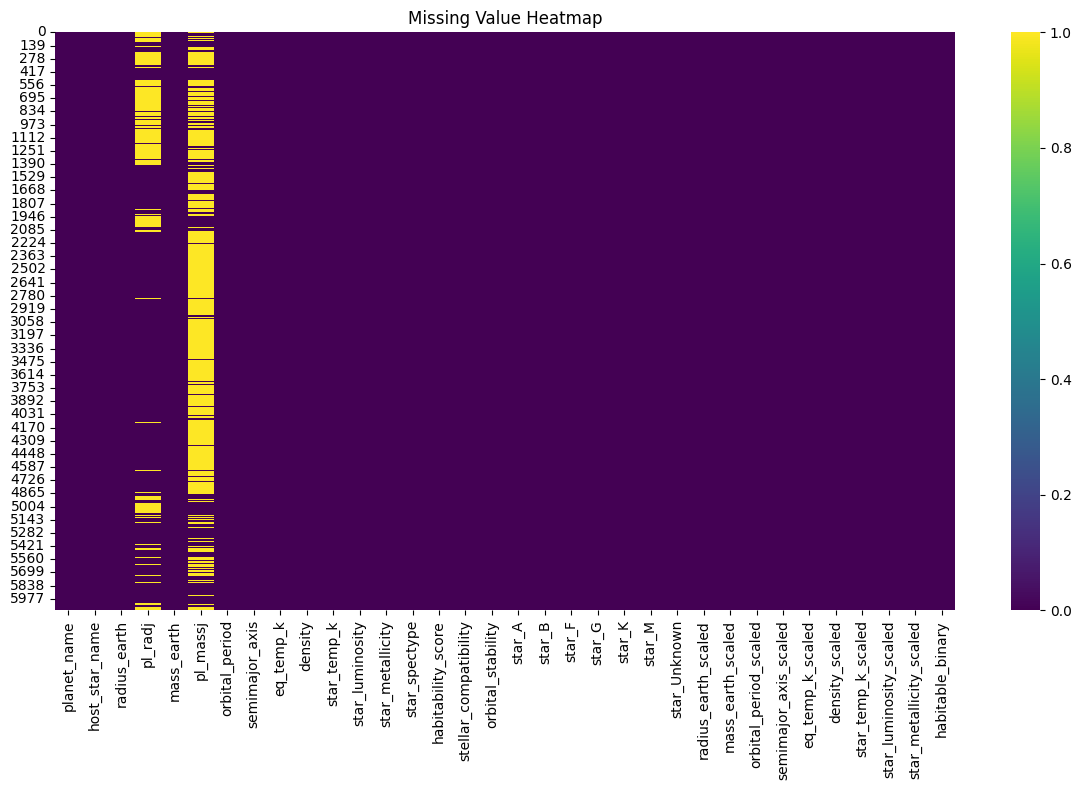

In [122]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=True,cmap = 'viridis')
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()

In [123]:
print("Unique planets:", df['planet_name'].nunique())

Unique planets: 6100


In [124]:
# ===============================
# Duplicate Row Check
# ===============================

duplicate_count = df.duplicated().sum()
print("Total Duplicate Rows:", duplicate_count)

Total Duplicate Rows: 0


In [125]:
# Show duplicate rows
df[df.duplicated()]

,planet_name,host_star_name,radius_earth,pl_radj,mass_earth,pl_massj,orbital_period,semimajor_axis,eq_temp_k,density,...,radius_earth_scaled,mass_earth_scaled,orbital_period_scaled,semimajor_axis_scaled,eq_temp_k_scaled,density_scaled,star_temp_k_scaled,star_luminosity_scaled,star_metallicity_scaled,habitable_binary


In [126]:
# Duplicate planet names
if "planet_name" in df.columns:
    print("Duplicate planet_name entries:",
          df["planet_name"].duplicated().sum())

Duplicate planet_name entries: 0


In [127]:
# Remove full-row duplicates
df = df.drop_duplicates()

print("Duplicates removed.")
print("New shape:", df.shape)

Duplicates removed.
New shape: (6100, 34)


In [128]:
df = df.drop_duplicates(subset=["planet_name"], keep="first")

print("Duplicate planets removed.")
print("New shape:", df.shape)

Duplicate planets removed.
New shape: (6100, 34)


In [129]:
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


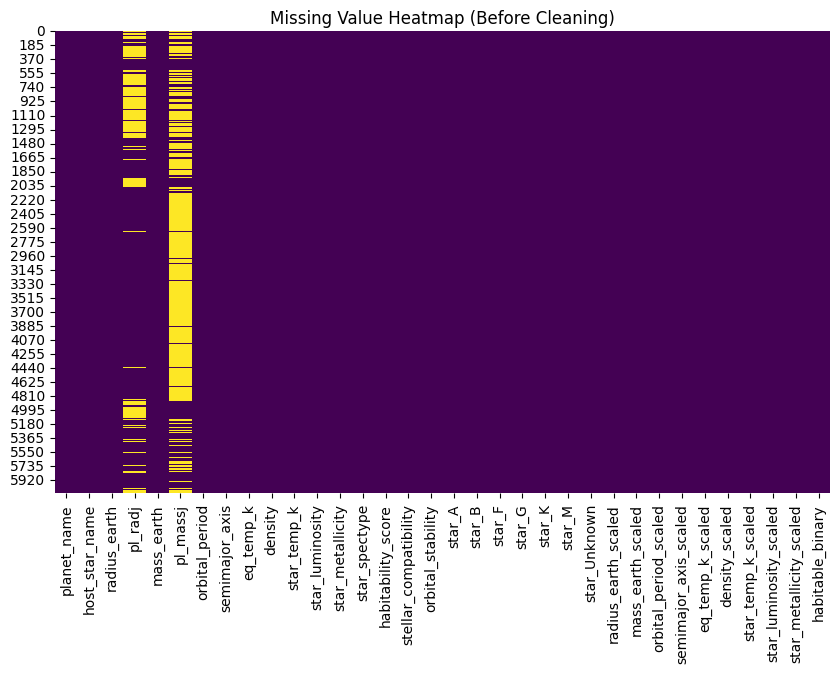

In [130]:
# 1. Missing Value Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap (Before Cleaning)')
plt.show()

In [131]:
# Features
X = df.drop("habitable_binary", axis=1)

# Target
y = df["habitable_binary"]

In [132]:
missing = X.isnull().sum()
missing = missing[missing > 0]

print("Columns with missing values:")
print(missing)

Columns with missing values:
pl_radj     1519
pl_massj    4146
dtype: int64


In [133]:
# ===============================
# Feature Engineering
# ===============================

TARGET = "habitable_binary"

DROP_COLUMNS = [
    "planet_name",
    "host_star_name",
    "star_spectype"
]

def prepare_features(df: pd.DataFrame):
    X = df.drop(columns=DROP_COLUMNS + [TARGET])
    y = df[TARGET]
    return X, y

X, y = prepare_features(df)
print("Feature count:", X.shape[1])

Feature count: 30


In [134]:
# ===============================
# Preprocessing Pipeline
# ===============================

numeric_imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    numeric_imputer.fit_transform(X),
    columns=X.columns
)

In [135]:
# ===============================
# Train-Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4880, 30)
Test shape: (1220, 30)


In [136]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [137]:
# ===============================
# Model Factory
# ===============================

def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=3000),
        "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(
            n_estimators=400,
            random_state=RANDOM_STATE
        ),
        "XGBoost": XGBClassifier(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric="logloss",
            random_state=RANDOM_STATE
        )
    }

models = get_models()

In [138]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [139]:
y_pred = model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9967213114754099

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1215
           1       1.00      0.20      0.33         5

    accuracy                           1.00      1220
   macro avg       1.00      0.60      0.67      1220
weighted avg       1.00      1.00      1.00      1220



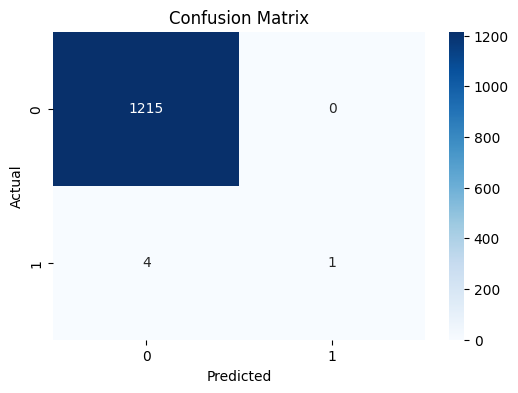

In [140]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

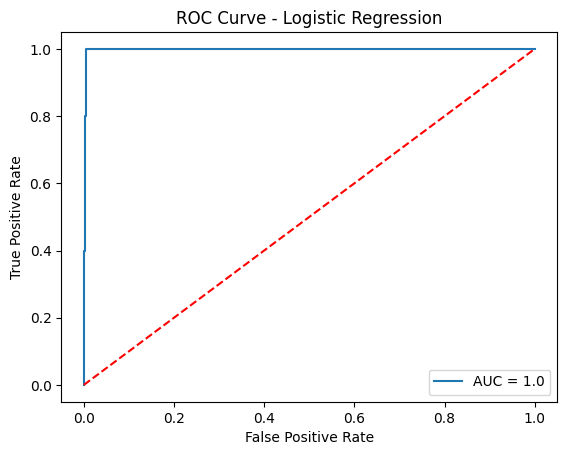

In [141]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

In [142]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

evaluate_model("Decision Tree", dt_model, X_train, X_test, y_train, y_test)


===== Decision Tree =====
F1 Score: 0.6
ROC-AUC: 0.7992
[[1213    2]
 [   2    3]]


(0.6,
 np.float64(0.7991769547325104),
 DecisionTreeClassifier(max_depth=5, random_state=42))

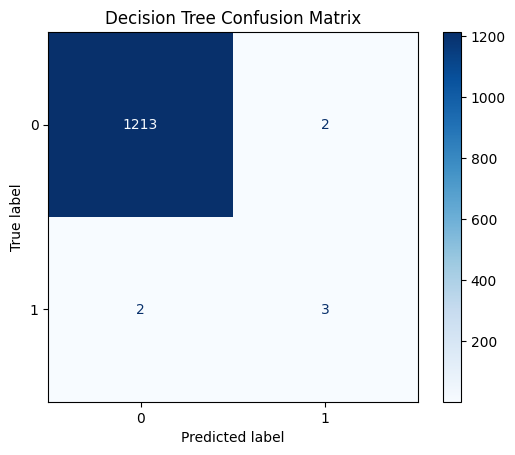

In [143]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = dt_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.show()

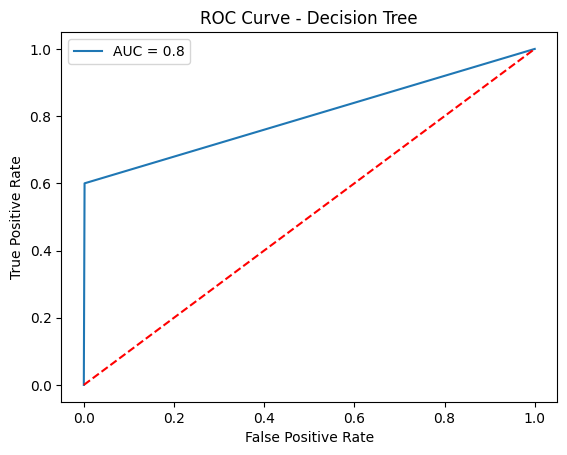

In [144]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = dt_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()

plt.show()

In [145]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

evaluate_model("Random Forest", rf_model, X_train, X_test, y_train, y_test)


===== Random Forest =====
F1 Score: 0.75
ROC-AUC: 0.8
[[1215    0]
 [   2    3]]


(0.75, np.float64(0.8), RandomForestClassifier(random_state=42))

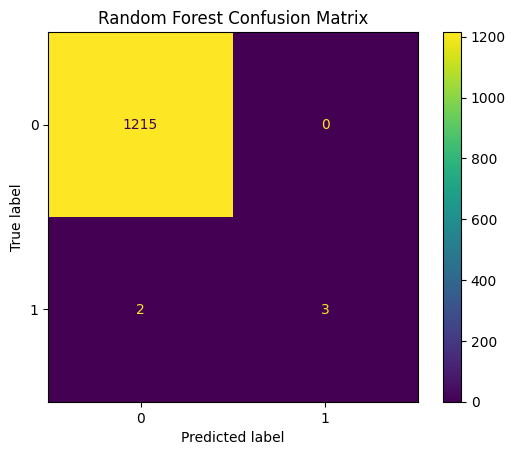

In [146]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# prediction
y_pred = rf_model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# graph
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

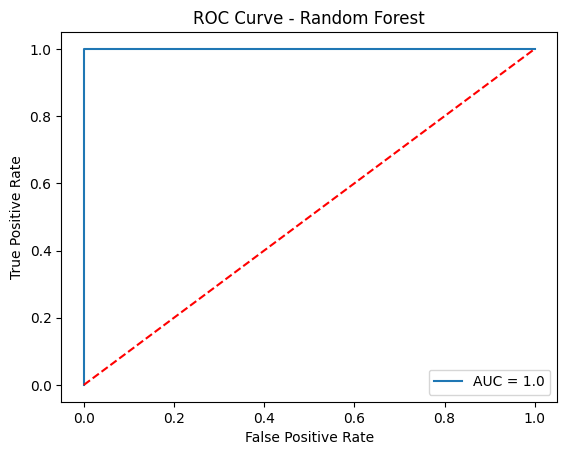

In [147]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# probability prediction
y_prob = rf_model.predict_proba(X_test)[:,1]

# roc calculation
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

# plot
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

In [148]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier()

evaluate_model("XGBoost", xgb_model, X_train, X_test, y_train, y_test)


===== XGBoost =====
F1 Score: 1.0
ROC-AUC: 1.0
[[1215    0]
 [   0    5]]


(1.0,
 np.float64(1.0),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...))

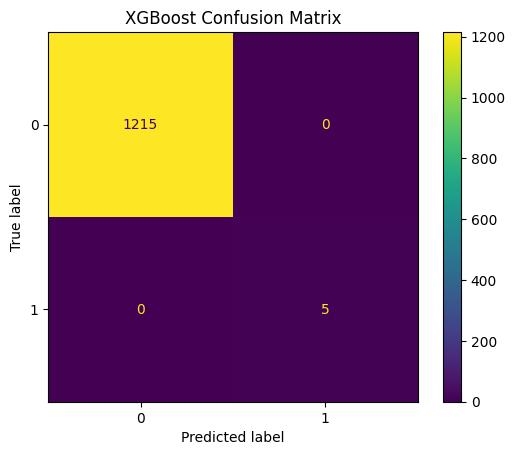

In [149]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# prediction
y_pred = xgb_model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# graph display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

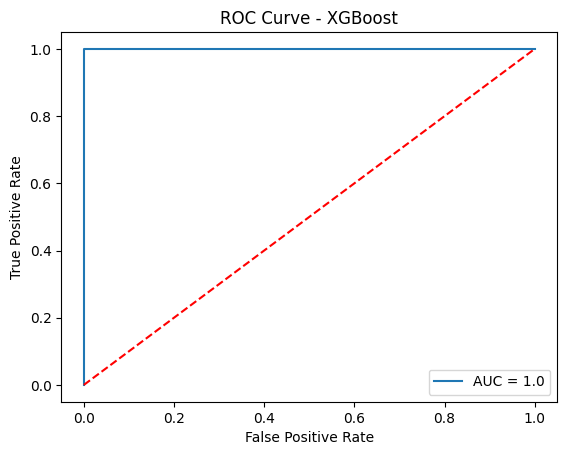

In [150]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# probability prediction
y_prob = xgb_model.predict_proba(X_test)[:,1]

# calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

In [151]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [152]:
evaluate_model("Logistic Regression", model, X_train, X_test, y_train, y_test)

evaluate_model("Decision Tree", dt_model, X_train, X_test, y_train, y_test)

evaluate_model("Random Forest", rf_model, X_train, X_test, y_train, y_test)

evaluate_model("XGBoost", xgb_model, X_train, X_test, y_train, y_test)



===== Logistic Regression =====
F1 Score: 0.3333
ROC-AUC: 0.6
[[1215    0]
 [   4    1]]

===== Decision Tree =====
F1 Score: 0.6
ROC-AUC: 0.7992
[[1213    2]
 [   2    3]]

===== Random Forest =====
F1 Score: 0.75
ROC-AUC: 0.8
[[1215    0]
 [   2    3]]

===== XGBoost =====
F1 Score: 1.0
ROC-AUC: 1.0
[[1215    0]
 [   0    5]]


(1.0,
 np.float64(1.0),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...))

In [153]:
# ===============================
# Benchmark All Models
# ===============================

results = []

for name, model in models.items():
    f1, auc, trained_model = evaluate_model(
        name, model, X_train, X_test, y_train, y_test
    )
    results.append((name, f1, auc, trained_model))

results_df = pd.DataFrame(results, columns=["Model", "F1", "ROC_AUC", "Model_Object"])
results_df = results_df.sort_values("F1", ascending=False)

results_df[["Model", "F1", "ROC_AUC"]]


===== Logistic Regression =====
F1 Score: 0.3333
ROC-AUC: 0.6
[[1215    0]
 [   4    1]]

===== Decision Tree =====
F1 Score: 0.6
ROC-AUC: 0.7992
[[1213    2]
 [   2    3]]

===== Random Forest =====
F1 Score: 0.75
ROC-AUC: 0.8
[[1215    0]
 [   2    3]]

===== XGBoost =====
F1 Score: 0.8889
ROC-AUC: 0.9
[[1215    0]
 [   1    4]]


,Model,F1,ROC_AUC
3,XGBoost,0.888889,0.900000
2,Random Forest,0.750000,0.800000
1,Decision Tree,0.600000,0.799177
0,Logistic Regression,0.333333,0.600000


In [154]:
import pandas as pd

comparison_df = pd.DataFrame(results).T
print(comparison_df)

                                   0  \
0                Logistic Regression   
1                           0.333333   
2                                0.6   
3  LogisticRegression(max_iter=3000)   

                                                   1  \
0                                      Decision Tree   
1                                                0.6   
2                                           0.799177   
3  DecisionTreeClassifier(max_depth=5, random_sta...   

                                                   2  \
0                                      Random Forest   
1                                               0.75   
2                                                0.8   
3  (DecisionTreeClassifier(max_features='sqrt', r...   

                                                   3  
0                                            XGBoost  
1                                           0.888889  
2                                                0.9  
3  XGBClassifier(

In [155]:
from sklearn.metrics import accuracy_score

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9983606557377049


In [156]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        logistic_pipeline.score(X_test, y_test),
        dt_model.score(X_test, y_test),
        rf_model.score(X_test, y_test),
        xgb_model.score(X_test, y_test)
    ]
})

print(comparison_df)

                 Model  Accuracy
0  Logistic Regression  0.996721
1        Decision Tree  0.996721
2        Random Forest  0.998361
3              XGBoost  1.000000


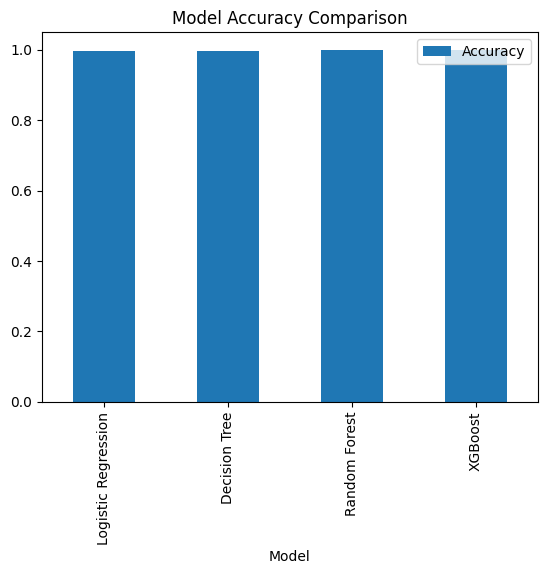

In [157]:
import matplotlib.pyplot as plt

comparison_df.plot(x="Model", y="Accuracy", kind="bar")

plt.title("Model Accuracy Comparison")
plt.show()

In [158]:
# ===============================
# Final Model Selection
# ===============================

best_row = results_df.iloc[0]
final_model = best_row["Model_Object"]

print("Selected Model:", best_row["Model"])

Selected Model: XGBoost


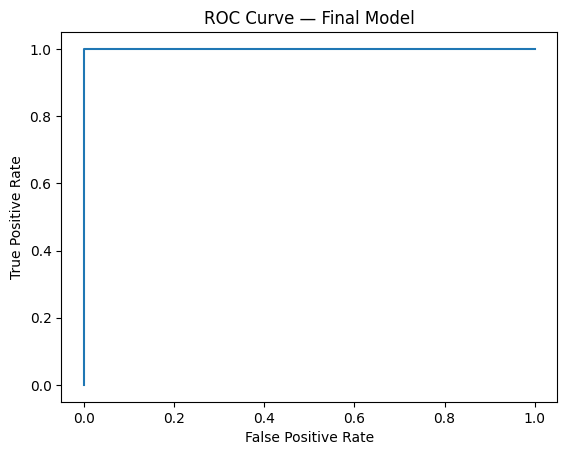

In [159]:
# ===============================
# ROC Curve
# ===============================

probs = final_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve — Final Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [160]:
# ===============================
# Habitability Scoring
# ===============================

df["habitability_score"] = final_model.predict_proba(X)[:,1]
df = df.sort_values("habitability_score", ascending=False)

df.head()

,planet_name,host_star_name,radius_earth,pl_radj,mass_earth,pl_massj,orbital_period,semimajor_axis,eq_temp_k,density,...,radius_earth_scaled,mass_earth_scaled,orbital_period_scaled,semimajor_axis_scaled,eq_temp_k_scaled,density_scaled,star_temp_k_scaled,star_luminosity_scaled,star_metallicity_scaled,habitable_binary
1890,K2-9 b,K2-9,1.60,0.142742,196.050555,NaN,18.448830,0.0848,284.0,1.33,...,-0.661290,0.0,0.241043,-0.094980,-1.492918,0.00,-2.306809,0.00000,-2.095238,1
2916,Kepler-1593 b,Kepler-1593,1.74,0.155233,196.050555,NaN,174.510276,0.4836,186.0,1.33,...,-0.548387,0.0,5.351079,1.898597,-1.770538,0.00,-1.323489,0.00000,-6.857143,0
2180,Kepler-1058 b,Kepler-1058,2.12,0.189134,196.050555,NaN,110.965460,0.3679,239.0,1.33,...,-0.241935,0.0,3.270384,1.320219,-1.620397,0.00,-1.242549,0.00000,-4.000000,0
3110,Kepler-174 d,Kepler-174,2.10,0.187350,196.050555,NaN,247.354265,0.6448,194.0,1.33,...,-0.258065,0.0,7.736264,2.704425,-1.747875,0.00,-1.079573,0.00000,-2.952381,0
4860,L 98-59 f,L 98-59,2.42,NaN,196.050555,NaN,23.064000,0.1052,285.0,5.00,...,0.000000,0.0,0.392161,0.006999,-1.490085,3.67,-2.364780,-1.88677,-2.095238,0


In [161]:
# ===============================
# Model Export
# ===============================

joblib.dump(final_model, "exoHabitAI_production_model.pkl")
df.to_csv("exoHabitAI_ranked_output.csv", index=False)

print("Production artifacts saved successfully.")

Production artifacts saved successfully.


In [164]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1215
           1       1.00      0.60      0.75         5

    accuracy                           1.00      1220
   macro avg       1.00      0.80      0.87      1220
weighted avg       1.00      1.00      1.00      1220



In [166]:
from sklearn.model_selection import RandomizedSearchCV

xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    xgb_params,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

best_xgb = xgb_random.best_estimator_

print("Best XGB Parameters:", xgb_random.best_params_)

evaluate_model(best_xgb, X_test, y_test, "Tuned XGBoost")

Best XGB Parameters: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}


TypeError: evaluate_model() missing 2 required positional arguments: 'y_train' and 'y_test'